In [41]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_human_capital import ModelClass, constraints

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint

from IPython.display import display, Math

from plots import plot_series

model = ModelClass()

par = model.par
sol = model.sol
sim = model.sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This model is used to find a certain condition. Currently, I just minimize the change in average wage level, because it was not easy to get by just setting parameters.

In [ ]:
param_spec = {
    "Q_a_shape": {"value": par.Q_a_shape, "bounds": (0.00001, 0.1), "active": True},
    "phi":   {"value": par.phi,  "bounds": (0.01, 0.99),  "active": True},
    "alpha":    {"value": par.alpha,  "bounds": (0.01, 0.99),  "active": True},
    "mu":     {"value": par.mu,  "bounds": (1.0, 10.0), "active": True},
    "c":        {"value": par.c,  "bounds": (0.1, 1000.0),  "active": True},
}


active_names = [k for k, v in param_spec.items() if v["active"]]
x0 = np.array([param_spec[k]["value"] for k in active_names], dtype=float)
bounds = [param_spec[k]["bounds"] for k in active_names]

def apply_params(par, names, values):
    for name, val in zip(names, values):
        setattr(par, name, float(val))
    return par

def objective(x):
    # Initialize all non-active parameters to their default values
    model.setup()

    for name, spec in param_spec.items():
        if not spec["active"]:
            setattr(par, name, spec["value"])

    apply_params(par, active_names, x)

    model.solve(do_print=False)

    model.simulate_transition()

    wage_gap_sim = (
        np.average(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::], axis=1)
        - np.average(model.sim.avg_wage[:, :5] / model.sim.avg_wage[0, :5], axis=1)
    ) * 100

    wage_gap_data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

    SSE = np.sum((wage_gap_sim - wage_gap_data)**2)

    return SSE


def optimize_and_plot(single_run=True, optimizer_trials=2):
    runs = []

    n_runs = 1 if single_run else optimizer_trials

    for i in range(n_runs):
        x0_random = np.array([np.random.uniform(low, high) for (low, high) in bounds], dtype=float)

        result = minimize(
            objective,
            x0=x0_random,
            bounds=bounds,
            method="Nelder-Mead",
            options={'maxiter': 20000, 'disp': False}
        )

        runs.append(result)

        print(list(result.x), result.fun)

    model.setup()

    result = min(runs, key=lambda r: r.fun)

    optimized_values = result.x
    apply_params(par, active_names, optimized_values)

    print("Success:", result.success)
    print("Message:", result.message)
    print("Objective value:", result.fun)
    print("Optimized parameters:")
    for name in active_names:
        print("par." + name + " = ", getattr(par, name))

    
    model.solve()
    model.simulate_transition()

    wage_gap = (
        np.average(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::], axis=1)
        - np.average(model.sim.avg_wage[:, :5] / model.sim.avg_wage[0, :5], axis=1)
    ) * 100

    plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")

    return runs, optimized_values

runs, optimized_values = optimize_and_plot(single_run=False, optimizer_trials=100)

[np.float64(1.000000000053878e-05), np.float64(0.5949571307767307), np.float64(0.01), np.float64(10.0), np.float64(3.698645349938565)] 7288.082043625331
[np.float64(0.000863088763830461), np.float64(0.6198139438362307), np.float64(0.010000050856573135), np.float64(8.821362807496165), np.float64(46.19900418522023)] 7253.194753548845
[np.float64(0.09825494192053041), np.float64(0.6516830543306349), np.float64(0.010011996133980445), np.float64(1.0000000306100953), np.float64(171.608977199769)] 7155.090369902263
[np.float64(0.1), np.float64(0.7086015520179844), np.float64(0.99), np.float64(1.0), np.float64(1000.0)] 7537.196988527132
[np.float64(0.01657486851480184), np.float64(0.6193143181788217), np.float64(0.010001725319207688), np.float64(10.0), np.float64(46.198860109831)] 7253.853977283695
[np.float64(0.07833171891562399), np.float64(0.99), np.float64(0.08664100594105217), np.float64(10.0), np.float64(71.0047145979369)] 5341.658986128144


c:\Users\per.eco\Documents\GitHub\Danish-Wage-Gap-Model\main_human_capital.py:385: RuntimeWarning: divide by zero encountered in scalar power
  return (1 - par.alpha)*(Ll)**(par.alpha)*(Lh)**(- par.alpha)


[np.float64(0.05071935228997332), np.float64(0.6991192335516123), np.float64(0.018898340303753744), np.float64(1.0), np.float64(854.9521554348516)] 7027.168251703595
[np.float64(1.0000000000000003e-05), np.float64(0.6505445775139407), np.float64(0.010000131689857812), np.float64(1.0), np.float64(186.2456090032781)] 7154.690932560483
[np.float64(1.0000000000000006e-05), np.float64(0.651816629259578), np.float64(0.010004351882668825), np.float64(1.0), np.float64(197.1047426409018)] 7154.698942606685
[np.float64(3.3277215623728155e-05), np.float64(0.5999186955721425), np.float64(0.013491422786250928), np.float64(8.256037363121266), np.float64(4.6559884150416515)] 7289.144325658094
[np.float64(0.1), np.float64(0.6570079208888195), np.float64(0.013065682837338478), np.float64(1.000515506028083), np.float64(172.22614409118006)] 7158.1942976455775
[np.float64(0.09845690899239574), np.float64(0.6522812586297123), np.float64(0.010035030156569032), np.float64(1.0), np.float64(168.59985361956646)

par.phi =  0.9770522931764776
par.alpha =  0.8871046214095553
par.mu =  6.243914738732712
par.c =  0.165253899037536
4006.4823591348686


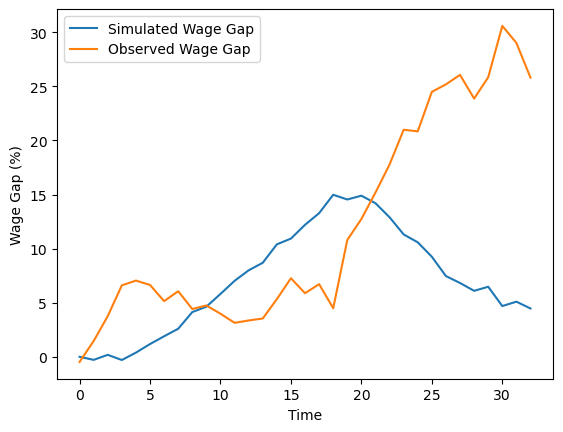

In [36]:
model.setup()

# optimized_values = [np.float64(0.623961436054632), np.float64(0.383503115066401), np.float64(10.0), np.float64(84.00874005478093)]
optimized_values = [np.float64(0.9770522931764776), np.float64(0.8871046214095553), np.float64(6.243914738732712), np.float64(0.165253899037536)]

apply_params(par, active_names, optimized_values)

for name in active_names:
    print("par." + name + " = ", getattr(par, name))

model.solve()
model.simulate_transition()

wage_gap = (
    np.average(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::], axis=1)
    - np.average(model.sim.avg_wage[:, :5] / model.sim.avg_wage[0, :5], axis=1)
) * 100

data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

print(np.sum((wage_gap - data)**2))

plt.plot(wage_gap, label='Simulated Wage Gap')
plt.plot(data, label='Observed Wage Gap')
plt.xlabel('Time')
plt.ylabel('Wage Gap (%)')
plt.legend()
plt.show()

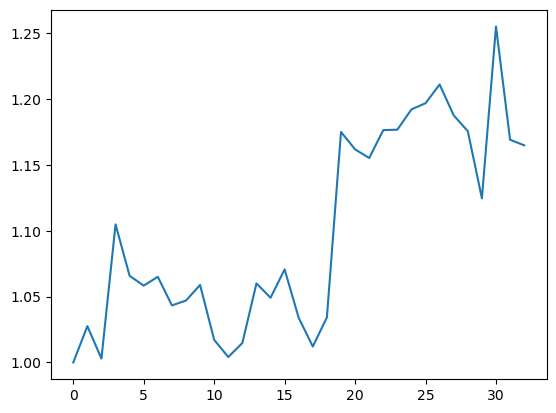

In [43]:
plt.plot(model.sim.avg_wage[:, :1] / model.sim.avg_wage[0, :1])

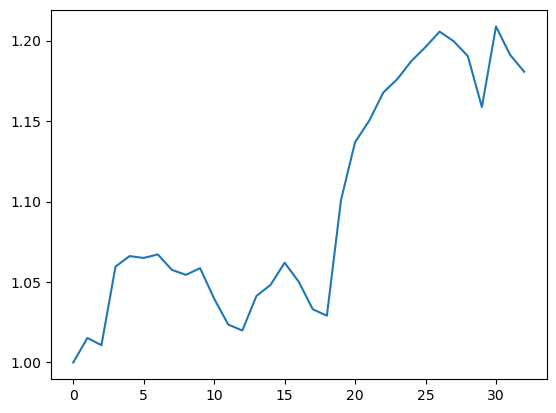

In [44]:
plt.plot(model.sim.avg_wage[:, -1::] / model.sim.avg_wage[0, -1::])

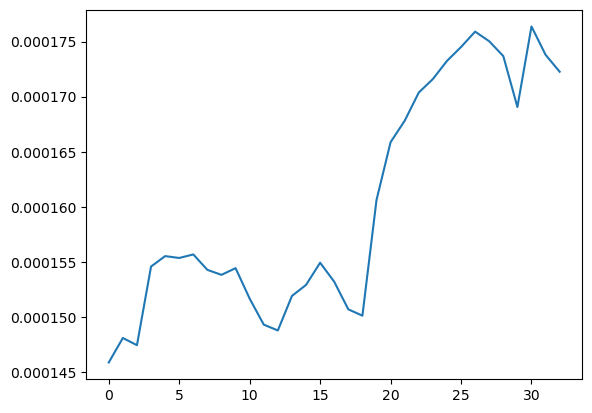

In [45]:
plt.plot(model.sim.avg_wage[:, -1])

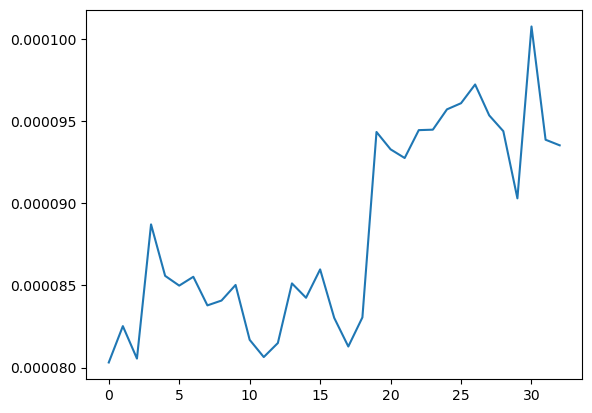

In [46]:
plt.plot(model.sim.avg_wage[:, 0])

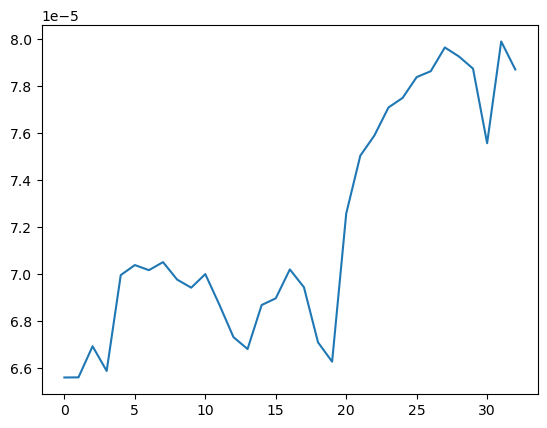

In [37]:
plt.plot(model.sim.avg_wage[:, -1] - model.sim.avg_wage[:, 0], label='Simulated Wage Gap')

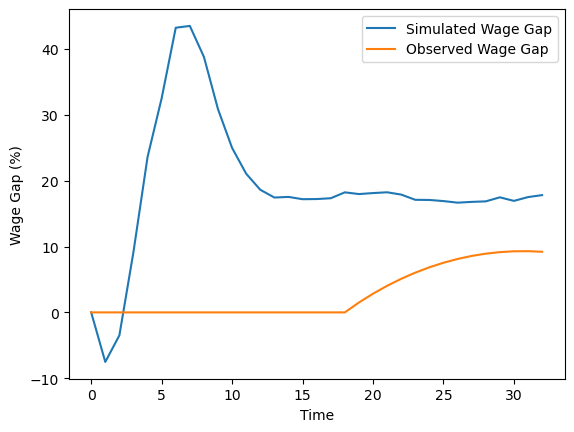